In [38]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/engraamirjamil/shoe-size-dataset/shoe_size_dataset.csv


In [39]:
#eda
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#filter warning 
import warnings as w
w.filterwarnings('ignore')


#set theme for plots
sns.set_style('darkgrid')

#Import Machine Learning Functins from different sub-Package
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

#time stamp
import time
print(f"Last Update:{time.asctime()}")

Last Update:Thu Aug 13 05:48:40 2026


In [40]:
#Load Dataset
df=pd.read_csv('/kaggle/input/datasets/engraamirjamil/shoe-size-dataset/shoe_size_dataset.csv')
df.head(2)

,height_cm,weight_kg,gender,shoe_size_us
0,177.4,96.8,Male,10.0
1,167.7,56.8,Female,6.0


In [41]:
df.shape

(500, 4)

In [42]:
df.dtypes

height_cm       float64
weight_kg       float64
gender           object
shoe_size_us    float64
dtype: object

In [43]:
#complete Info
df.info

<bound method DataFrame.info of      height_cm  weight_kg  gender  shoe_size_us
0        177.4       96.8    Male          10.0
1        167.7       56.8  Female           6.0
2        156.6       66.4  Female           4.0
3        154.1       78.5  Female           4.0
4        183.3       73.3    Male           9.5
..         ...        ...     ...           ...
495      170.3       88.4    Male           9.5
496      158.4       78.4  Female           4.0
497      179.7       73.1    Male           8.5
498      174.9       56.5  Female           6.0
499      166.5       64.7  Female           5.5

[500 rows x 4 columns]>

In [44]:
#Describe
df.describe()

,height_cm,weight_kg,shoe_size_us
count,500.000000,500.000000,500.000000
mean,168.490000,70.088400,6.697000
std,8.654966,12.667843,2.045987
min,146.700000,35.900000,4.000000
25%,162.275000,61.100000,4.875000
50%,168.050000,68.950000,6.500000
75%,174.800000,78.700000,8.500000
max,196.600000,104.300000,12.000000


In [45]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
height_cm,500.0,NaN,NaN,NaN,168.49,8.654966,146.7,162.275,168.05,174.8,196.6
weight_kg,500.0,NaN,NaN,NaN,70.0884,12.667843,35.9,61.1,68.95,78.7,104.3
gender,500,2,Female,259,NaN,NaN,NaN,NaN,NaN,NaN,NaN
shoe_size_us,500.0,NaN,NaN,NaN,6.697,2.045987,4.0,4.875,6.5,8.5,12.0


In [46]:
df.gender.value_counts()

gender
Female    259
Male      241
Name: count, dtype: int64

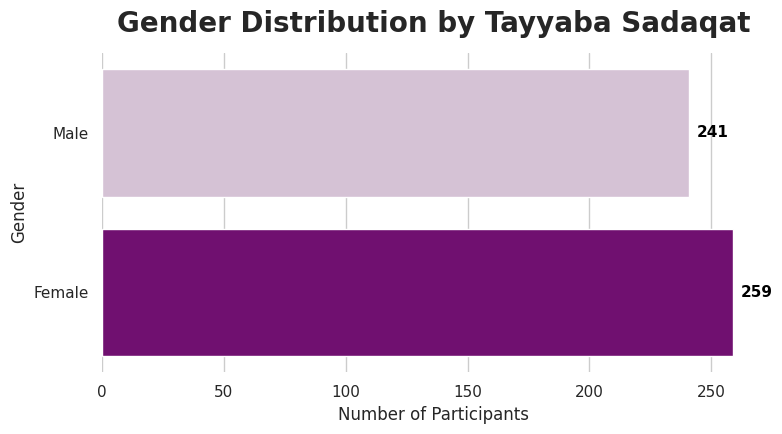

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Theme
sns.set_theme(style="whitegrid", context="notebook")

# Data
gender_counts = pd.Series({
    "Male": 241,
    "Female": 259
})

# Consistent color palette
colors = ["#d8bfd8", "#800080"]

# Figure
plt.figure(figsize=(8, 4.5))

ax = sns.barplot(
    x=gender_counts.values,
    y=gender_counts.index,
    hue=gender_counts.index,
    palette=colors,
    legend=False
)

# Title & labels
plt.title("Gender Distribution by Tayyaba Sadaqat",
          fontsize=20,
          fontweight="bold",
          pad=15)

plt.xlabel("Number of Participants", fontsize=12)
plt.ylabel("Gender", fontsize=12)

# Value labels
for i, value in enumerate(gender_counts.values):
    ax.text(
        value + 3,
        i,
        value,
        va="center",
        fontsize=11,
        fontweight="bold",
        color="black"
    )

# Clean UI
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

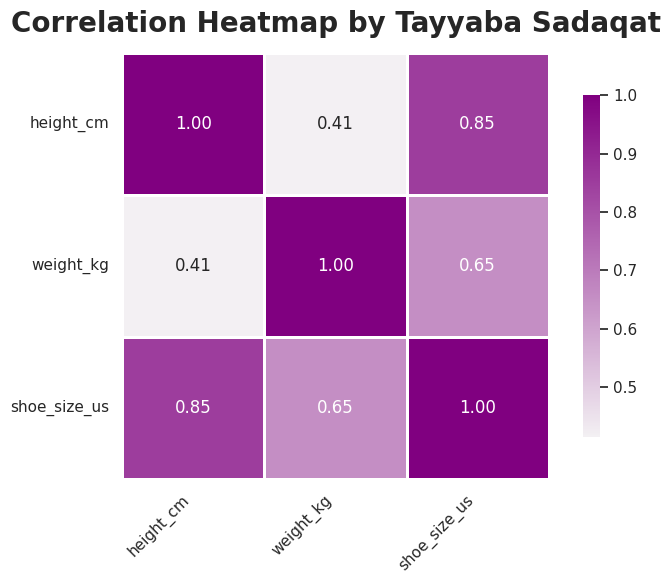

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Theme
sns.set_theme(style="whitegrid", context="notebook")

# Correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Figure
plt.figure(figsize=(8, 6))

# Heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap=sns.light_palette("#800080", as_cmap=True),
    fmt=".2f",
    linewidths=1,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.8}
)

# Title
plt.title(
    "Correlation Heatmap by Tayyaba Sadaqat",
    fontsize=20,
    fontweight="bold",
    pad=15
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

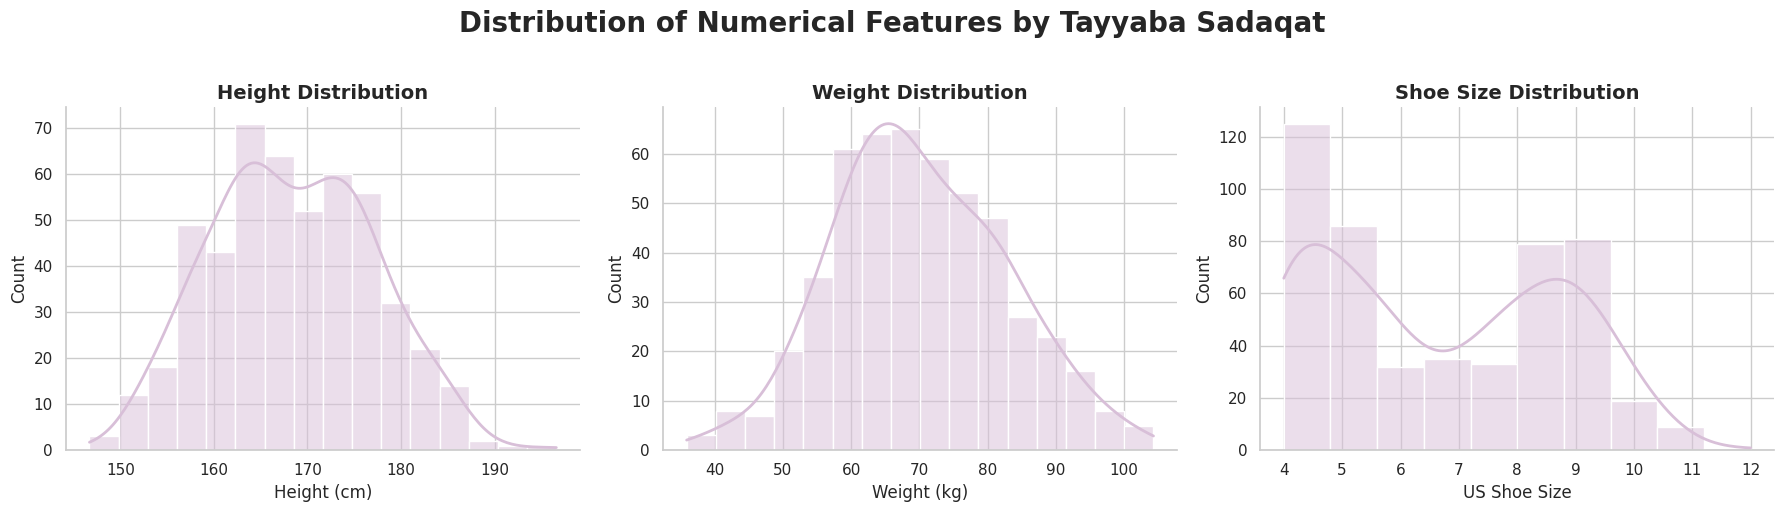

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Theme
sns.set_theme(style="whitegrid", context="notebook")

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Colors
fill_color = "#d8bfd8"
line_color = "#800080"

# Height Distribution
sns.histplot(
    data=df,
    x="height_cm",
    kde=True,
    color=fill_color,
    line_kws={"color": line_color, "linewidth": 2},
    ax=axes[0]
)
axes[0].set_title("Height Distribution", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Height (cm)")
axes[0].set_ylabel("Count")

# Weight Distribution
sns.histplot(
    data=df,
    x="weight_kg",
    kde=True,
    color=fill_color,
    line_kws={"color": line_color, "linewidth": 2},
    ax=axes[1]
)
axes[1].set_title("Weight Distribution", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Weight (kg)")
axes[1].set_ylabel("Count")

# Shoe Size Distribution
sns.histplot(
    data=df,
    x="shoe_size_us",
    kde=True,
    color=fill_color,
    line_kws={"color": line_color, "linewidth": 2},
    ax=axes[2]
)
axes[2].set_title("Shoe Size Distribution", fontsize=14, fontweight="bold")
axes[2].set_xlabel("US Shoe Size")
axes[2].set_ylabel("Count")

# Overall Title
fig.suptitle(
    "Distribution of Numerical Features by Tayyaba Sadaqat",
    fontsize=20,
    fontweight="bold",
    y=1.02
)

# Clean UI
sns.despine()
plt.tight_layout()
plt.show()

# Data Processing 

## Label Encoding

In [50]:
le=LabelEncoder()
df['gender']=le.fit_transform(df['gender'])

In [51]:
X=df.drop('shoe_size_us',axis=1)
y=df['shoe_size_us']

### Feature and Target Split 

In [52]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

### Scalling 

In [53]:
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.fit_transform(X_test)

In [54]:
from sklearn.preprocessing import (
    MinMaxScaler,
    StandardScaler,
    RobustScaler,
    MaxAbsScaler
)

In [55]:
# Sample Dataset

data = {
    "Height_CM": [150,155,160,165,170,175,180,185,190,195],
    "Weight_Kg": [45,50,55,60,65,70,75,80,85,90],
    "Shoe_Size_US": [5,6,7,8,8,9,10,11,12,13]
}

df = pd.DataFrame(data)

print("Original Dataset")
display(df)

Original Dataset


,Height_CM,Weight_Kg,Shoe_Size_US
0,150,45,5
1,155,50,6
2,160,55,7
3,165,60,8
4,170,65,8
5,175,70,9
6,180,75,10
7,185,80,11
8,190,85,12
9,195,90,13


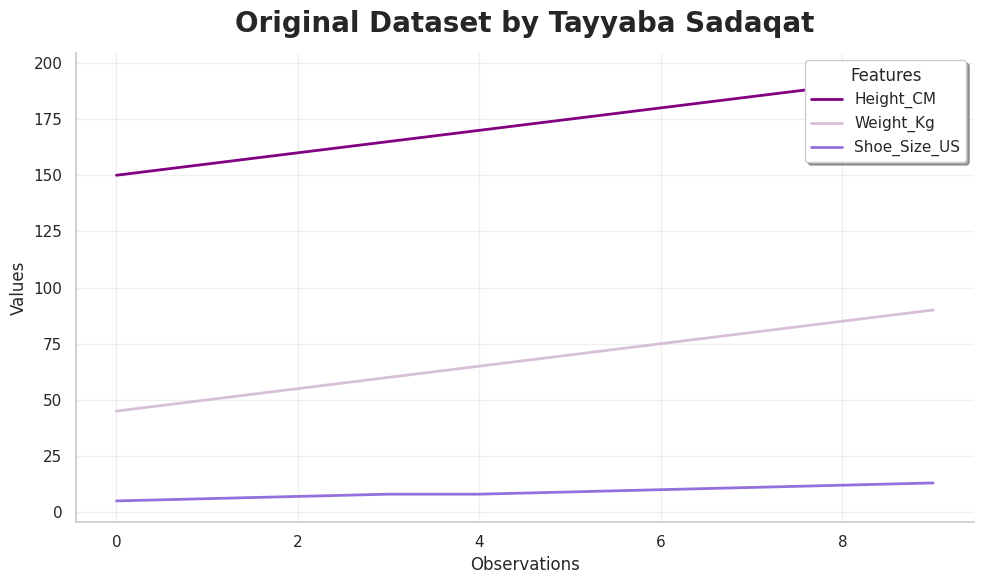

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Theme
sns.set_theme(style="whitegrid", context="notebook")

# Consistent color palette
colors = ["#800080", "#d8bfd8", "#9370DB", "#BA55D3"]

plt.figure(figsize=(10, 6))

# Plot each numerical column
for i, column in enumerate(df.columns):
    plt.plot(
        df[column],
        label=column,
        color=colors[i % len(colors)],
        linewidth=2
    )

# Title
plt.title(
    "Original Dataset by Tayyaba Sadaqat",
    fontsize=20,
    fontweight="bold",
    pad=15
)

# Labels
plt.xlabel("Observations", fontsize=12)
plt.ylabel("Values", fontsize=12)

# Legend
plt.legend(
    title="Features",
    loc="upper right",
    frameon=True,
    fancybox=True,
    shadow=True
)

# Grid
plt.grid(alpha=0.3)

# Clean look
sns.despine()

plt.tight_layout()
plt.show()

In [57]:
scaler = MinMaxScaler()

minmax_df = pd.DataFrame(
    scaler.fit_transform(df),
    columns=df.columns
)

print("Min-Max Scaled Data")
display(minmax_df)

Min-Max Scaled Data


,Height_CM,Weight_Kg,Shoe_Size_US
0,0.000000,0.000000,0.000
1,0.111111,0.111111,0.125
2,0.222222,0.222222,0.250
3,0.333333,0.333333,0.375
4,0.444444,0.444444,0.375
5,0.555556,0.555556,0.500
6,0.666667,0.666667,0.625
7,0.777778,0.777778,0.750
8,0.888889,0.888889,0.875
9,1.000000,1.000000,1.000


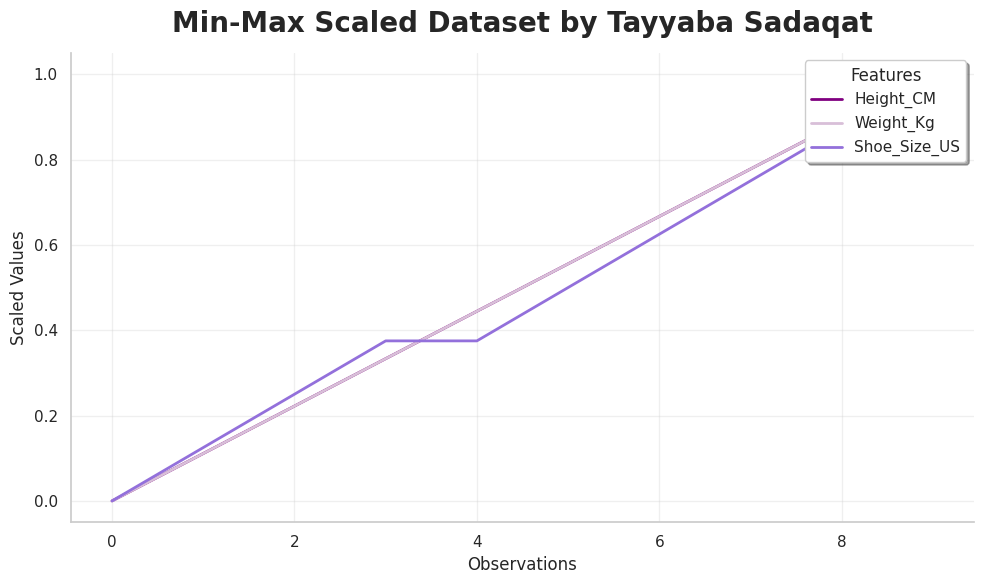

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# Theme
sns.set_theme(style="whitegrid", context="notebook")

# Consistent color palette
colors = ["#800080", "#d8bfd8", "#9370DB", "#BA55D3"]

plt.figure(figsize=(10, 6))

# Plot each scaled feature
for i, column in enumerate(minmax_df.columns):
    plt.plot(
        minmax_df[column],
        label=column,
        color=colors[i % len(colors)],
        linewidth=2
    )

# Title
plt.title(
    "Min-Max Scaled Dataset by Tayyaba Sadaqat",
    fontsize=20,
    fontweight="bold",
    pad=15
)

# Labels
plt.xlabel("Observations", fontsize=12)
plt.ylabel("Scaled Values", fontsize=12)

# Legend
plt.legend(
    title="Features",
    loc="upper right",
    frameon=True,
    fancybox=True,
    shadow=True
)

# Grid
plt.grid(alpha=0.3)

# Clean UI
sns.despine()

plt.tight_layout()
plt.show()

In [59]:
scaler = StandardScaler()

standard_df = pd.DataFrame(
    scaler.fit_transform(df),
    columns=df.columns
)

print("Standard Scaled Data")
display(standard_df)

Standard Scaled Data


,Height_CM,Weight_Kg,Shoe_Size_US
0,-1.566699,-1.566699,-1.580360
1,-1.218544,-1.218544,-1.175139
2,-0.870388,-0.870388,-0.769919
3,-0.522233,-0.522233,-0.364698
4,-0.174078,-0.174078,-0.364698
5,0.174078,0.174078,0.040522
6,0.522233,0.522233,0.445742
7,0.870388,0.870388,0.850963
8,1.218544,1.218544,1.256183
9,1.566699,1.566699,1.661404


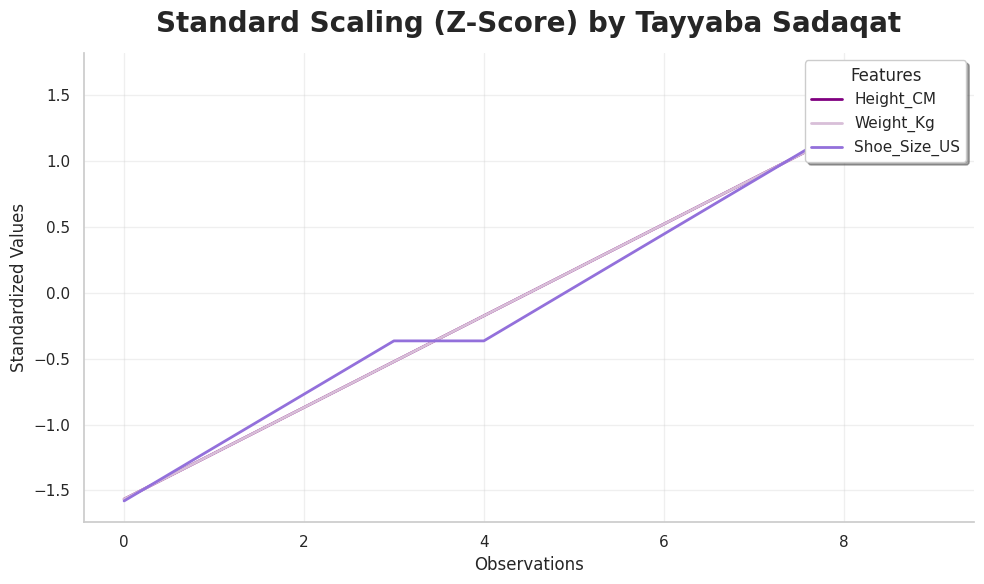

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# Theme
sns.set_theme(style="whitegrid", context="notebook")

# Consistent color palette
colors = ["#800080", "#d8bfd8", "#9370DB", "#BA55D3"]

plt.figure(figsize=(10, 6))

# Plot each standardized feature
for i, column in enumerate(standard_df.columns):
    plt.plot(
        standard_df[column],
        label=column,
        color=colors[i % len(colors)],
        linewidth=2
    )

# Title
plt.title(
    "Standard Scaling (Z-Score) by Tayyaba Sadaqat",
    fontsize=20,
    fontweight="bold",
    pad=15
)

# Labels
plt.xlabel("Observations", fontsize=12)
plt.ylabel("Standardized Values", fontsize=12)

# Legend
plt.legend(
    title="Features",
    loc="upper right",
    frameon=True,
    fancybox=True,
    shadow=True
)

# Grid
plt.grid(alpha=0.3)

# Clean UI
sns.despine()

plt.tight_layout()
plt.show()

In [61]:
scaler = RobustScaler()

robust_df = pd.DataFrame(
    scaler.fit_transform(df),
    columns=df.columns
)

print("Robust Scaled Data")
display(robust_df)

Robust Scaled Data


,Height_CM,Weight_Kg,Shoe_Size_US
0,-1.000000,-1.000000,-1.000000
1,-0.777778,-0.777778,-0.714286
2,-0.555556,-0.555556,-0.428571
3,-0.333333,-0.333333,-0.142857
4,-0.111111,-0.111111,-0.142857
5,0.111111,0.111111,0.142857
6,0.333333,0.333333,0.428571
7,0.555556,0.555556,0.714286
8,0.777778,0.777778,1.000000
9,1.000000,1.000000,1.285714


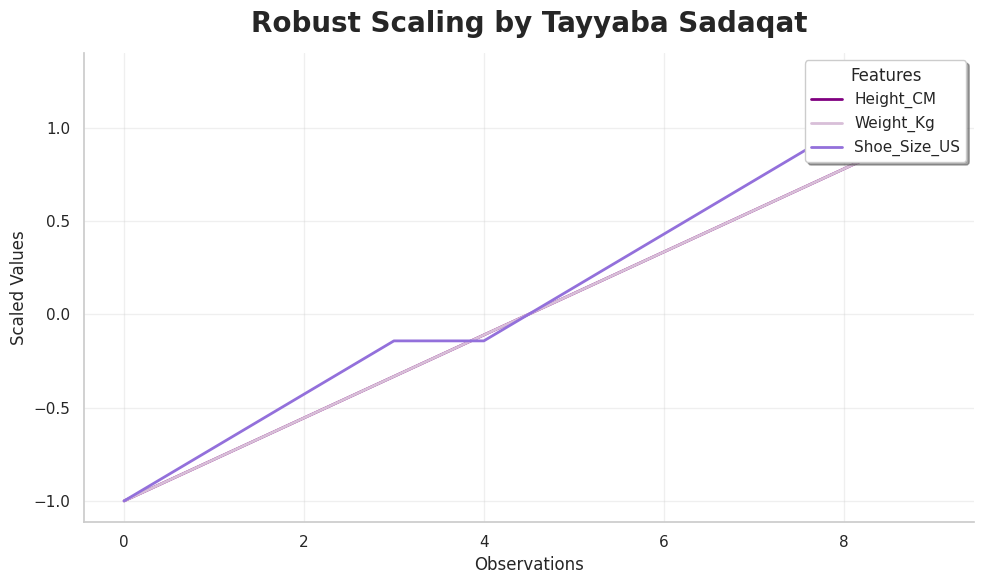

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

# Theme
sns.set_theme(style="whitegrid", context="notebook")

# Consistent color palette
colors = ["#800080", "#d8bfd8", "#9370DB", "#BA55D3"]

plt.figure(figsize=(10, 6))

# Plot each robust-scaled feature
for i, column in enumerate(robust_df.columns):
    plt.plot(
        robust_df[column],
        label=column,
        color=colors[i % len(colors)],
        linewidth=2
    )

# Title
plt.title(
    "Robust Scaling by Tayyaba Sadaqat",
    fontsize=20,
    fontweight="bold",
    pad=15
)

# Labels
plt.xlabel("Observations", fontsize=12)
plt.ylabel("Scaled Values", fontsize=12)

# Legend
plt.legend(
    title="Features",
    loc="upper right",
    frameon=True,
    fancybox=True,
    shadow=True
)

# Grid
plt.grid(alpha=0.3)

# Clean UI
sns.despine()

plt.tight_layout()
plt.show()

In [63]:
scaler = MaxAbsScaler()

maxabs_df = pd.DataFrame(
    scaler.fit_transform(df),
    columns=df.columns
)

print("Max Absolute Scaled Data")
display(maxabs_df)

Max Absolute Scaled Data


,Height_CM,Weight_Kg,Shoe_Size_US
0,0.769231,0.500000,0.384615
1,0.794872,0.555556,0.461538
2,0.820513,0.611111,0.538462
3,0.846154,0.666667,0.615385
4,0.871795,0.722222,0.615385
5,0.897436,0.777778,0.692308
6,0.923077,0.833333,0.769231
7,0.948718,0.888889,0.846154
8,0.974359,0.944444,0.923077
9,1.000000,1.000000,1.000000


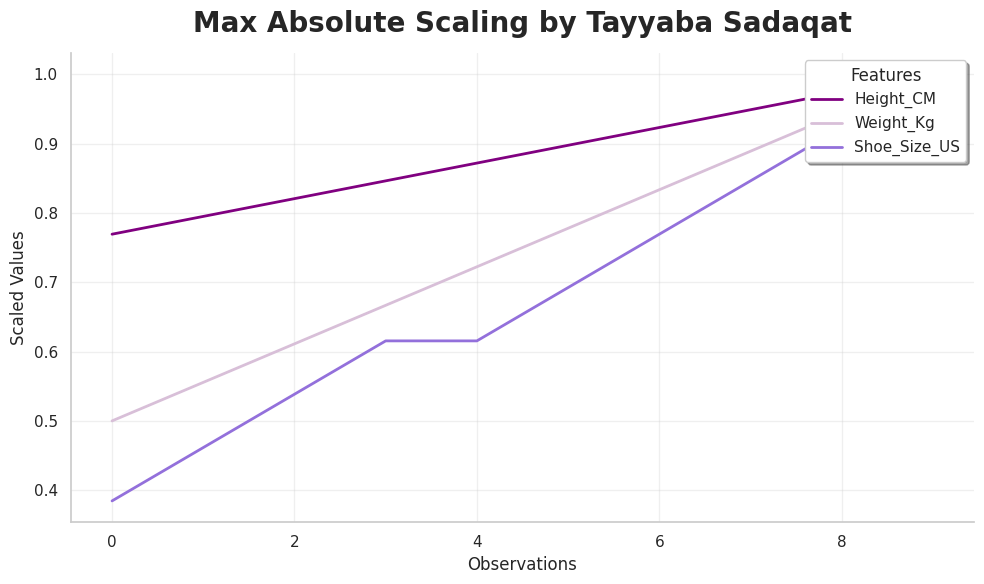

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

# Theme
sns.set_theme(style="whitegrid", context="notebook")

# Consistent color palette
colors = ["#800080", "#d8bfd8", "#9370DB", "#BA55D3"]

plt.figure(figsize=(10, 6))

# Plot each scaled feature
for i, column in enumerate(maxabs_df.columns):
    plt.plot(
        maxabs_df[column],
        label=column,
        color=colors[i % len(colors)],
        linewidth=2
    )

# Title
plt.title(
    "Max Absolute Scaling by Tayyaba Sadaqat",
    fontsize=20,
    fontweight="bold",
    pad=15
)

# Labels
plt.xlabel("Observations", fontsize=12)
plt.ylabel("Scaled Values", fontsize=12)

# Legend
plt.legend(
    title="Features",
    loc="upper right",
    frameon=True,
    fancybox=True,
    shadow=True
)

# Grid
plt.grid(alpha=0.3)

# Clean UI
sns.despine()

plt.tight_layout()
plt.show()

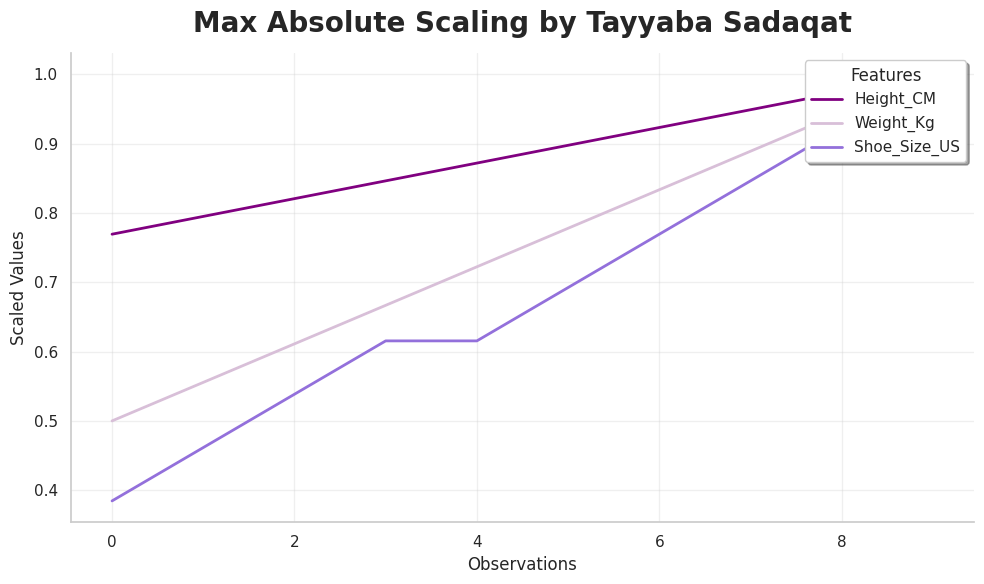

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

# Theme
sns.set_theme(style="whitegrid", context="notebook")

# Consistent color palette
colors = ["#800080", "#d8bfd8", "#9370DB", "#BA55D3"]

plt.figure(figsize=(10, 6))

# Plot each scaled feature
for i, column in enumerate(maxabs_df.columns):
    plt.plot(
        maxabs_df[column],
        label=column,
        color=colors[i % len(colors)],
        linewidth=2
    )

# Title
plt.title(
    "Max Absolute Scaling by Tayyaba Sadaqat",
    fontsize=20,
    fontweight="bold",
    pad=15
)

# Labels
plt.xlabel("Observations", fontsize=12)
plt.ylabel("Scaled Values", fontsize=12)

# Legend
plt.legend(
    title="Features",
    loc="upper right",
    frameon=True,
    fancybox=True,
    shadow=True
)

# Grid
plt.grid(alpha=0.3)

# Clean UI
sns.despine()

plt.tight_layout()
plt.show()

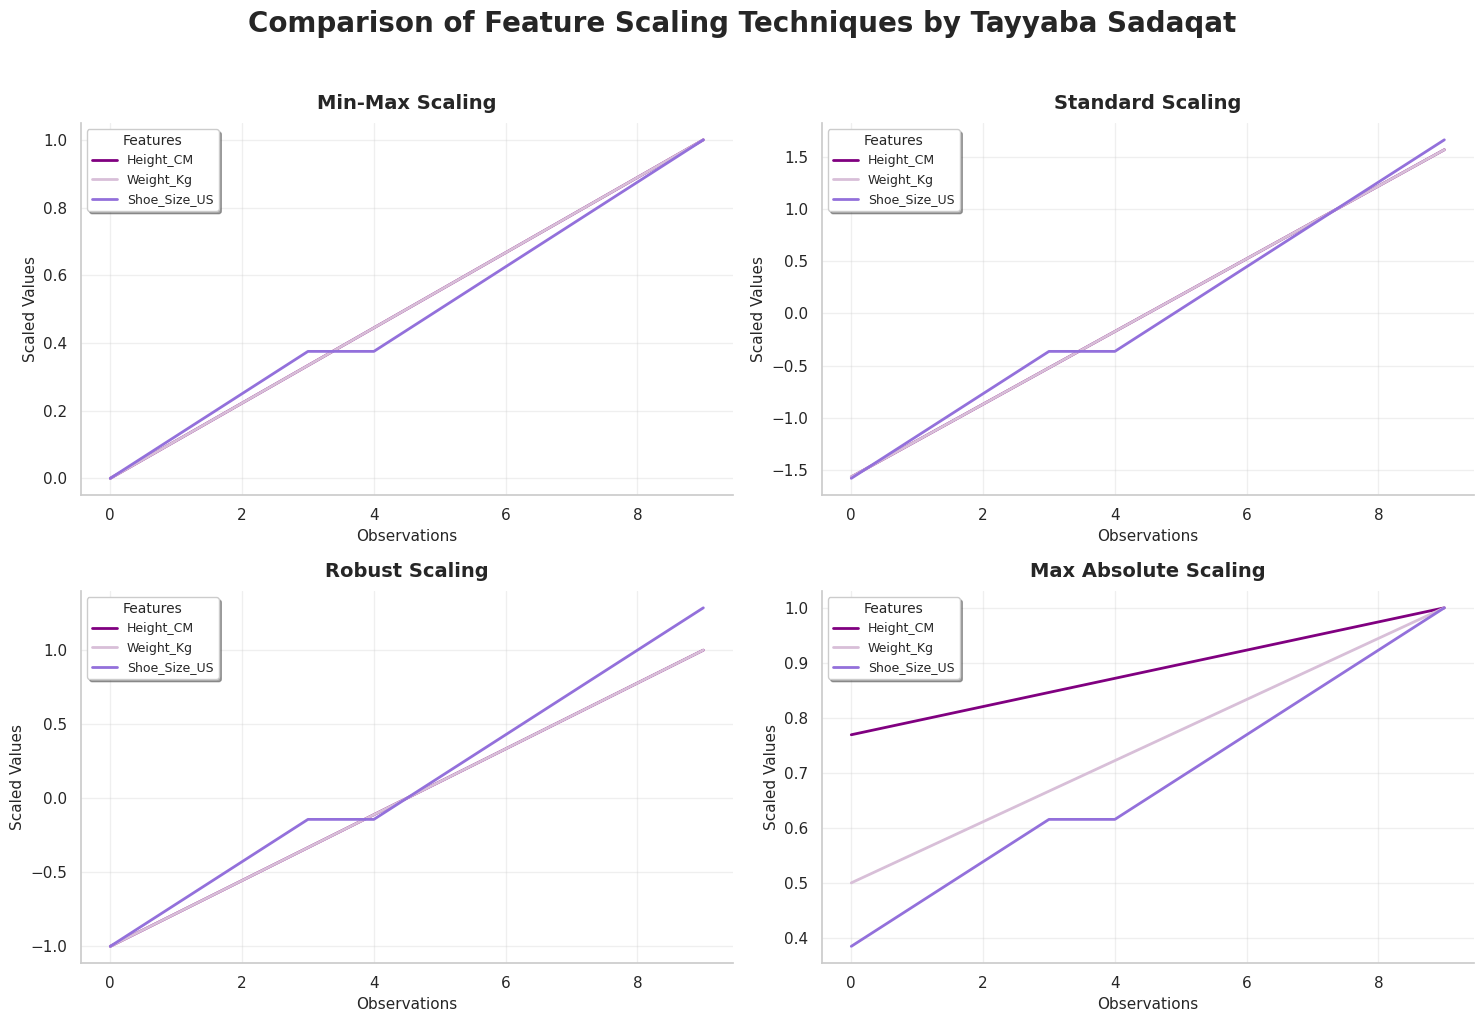

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# Theme
sns.set_theme(style="whitegrid", context="notebook")

# Consistent color palette
colors = ["#800080", "#d8bfd8", "#9370DB", "#BA55D3"]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

datasets = [
    (minmax_df, "Min-Max Scaling"),
    (standard_df, "Standard Scaling"),
    (robust_df, "Robust Scaling"),
    (maxabs_df, "Max Absolute Scaling")
]

for ax, (data, title) in zip(axes.flat, datasets):

    for i, column in enumerate(data.columns):
        ax.plot(
            data[column],
            label=column,
            color=colors[i % len(colors)],
            linewidth=2
        )

    ax.set_title(
        title,
        fontsize=14,
        fontweight="bold",
        pad=10
    )

    ax.set_xlabel("Observations", fontsize=11)
    ax.set_ylabel("Scaled Values", fontsize=11)

    ax.legend(
        title="Features",
        fontsize=9,
        title_fontsize=10,
        frameon=True,
        fancybox=True,
        shadow=True
    )

    ax.grid(alpha=0.3)
    sns.despine(ax=ax)

# Main Title
plt.suptitle(
    "Comparison of Feature Scaling Techniques by Tayyaba Sadaqat",
    fontsize=20,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

# Model Training

In [67]:
lg=LinearRegression()


In [68]:
#train model on data
lg.fit(X_train,y_train)

LinearRegression()

## Prediction 

In [69]:
y_pred=lg.predict(X_test)

In [70]:
y_test[:10],y_pred[:10]

(361    5.0
 73     4.5
 374    9.5
 155    9.5
 104    5.0
 394    7.0
 377    8.0
 124    6.5
 68     8.5
 450    4.0
 Name: shoe_size_us, dtype: float64,
 array([4.81010686, 4.40614416, 8.51824091, 8.3408217 , 5.22978609,
        7.83498526, 8.58793193, 7.29756936, 8.12679144, 3.75208993]))

## Metrices

In [71]:
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
r2s=r2_score(y_test,y_pred)

In [72]:
mae,mse,r2s

(0.47508161079977507, 0.34660174555165085, 0.9250084120510289)

### Save Model

In [75]:
import pickle

with open("/kaggle/working/shoe_size_model.pkl", "wb") as file:
    pickle.dump(lg, file)

print("Model saved successfully!")

Model saved successfully!


In [76]:
import os

print(os.path.exists("/kaggle/working/shoe_size_model.pkl"))
print(os.path.getsize("/kaggle/working/shoe_size_model.pkl"), "bytes")

True
452 bytes
